 Acknowledgements: Prof. Michael Bourke

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2

In [16]:
im = cv2.imread("../Perception/test_images/batman.jpg")

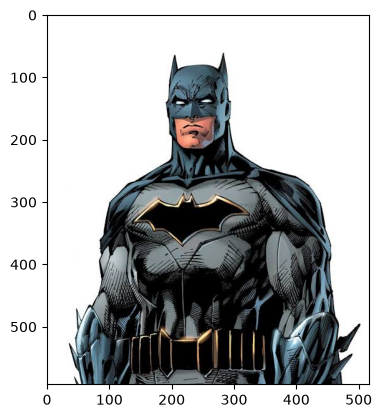

In [ ]:
plt.imshow(im[:,  :, [2,1, 0]])

In [12]:
print("The image size is: ",im.shape)
print("Images are typically stored as 8 bit unsigned integers. Type: ",im.dtype)
print("This means an image comprises values between 0 and 255.")

The image size is:  (593, 517, 3)
Images are typically stored as 8 bit unsigned integers. Type:  uint8
This means an image comprises values between 0 and 255.


In [18]:
print("The pixel value at row 10, column 10 is",im[10,10,:])

The pixel value at row 10, column 10 is [255 255 255]


# Understand RGB intensities

[Only look at the height of the blue solid line]

1. Towards the left of the first red line: color is white: all RGB are at max intensities.
2. Between the green lines, the color is mostly black, meaning all colors will be at their min intensities 0, 0, 0.
3. Again towards the right side of the second red line, everything is white.   

We will plot this and then you will see.

If you see row 180, then you will see a sudden surge of red color (row 180 shown by cyan horizontal line)

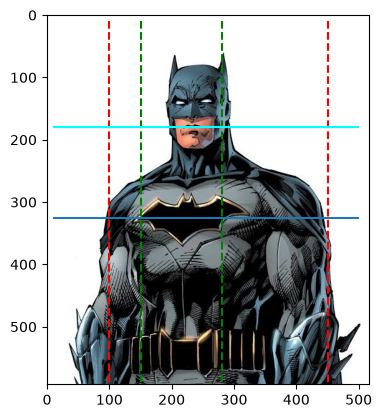

In [37]:
plt.imshow(im[:,  :, [2,1, 0]])
plt.vlines(100, 10, 590, linestyle="--",color= "red")
plt.vlines(450, 10, 590, linestyle="--",color= "red")
plt.vlines(150, 10, 590, linestyle="--",color= "green")
plt.vlines(280, 10, 590, linestyle="--",color= "green")

plt.hlines(325, 10, 500)
plt.hlines(180, 10, 500, color='cyan')

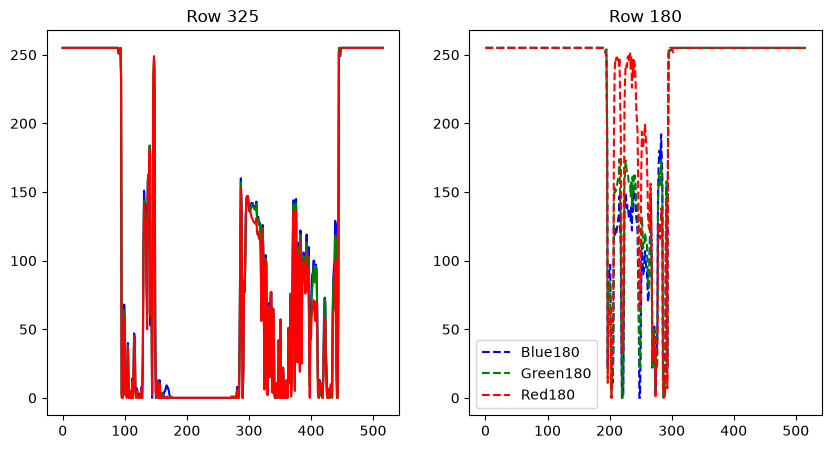

In [46]:
row325, row180 = im[325], im[180]
fig, axs = plt.subplots(1, 2, figsize=[10, 5])
axs[0].plot(row325[:, 0], color = "blue", label="Blue325")
axs[0].plot(row325[:, 1], color="green", label="Green325")
axs[0].plot(row325[:, 2], color="red", label="Red325")
axs[0].set_title("Row 325")

axs[1].plot(row180[:, 0], color = "blue", linestyle="--", label="Blue180")
axs[1].plot(row180[:, 1], color="green", linestyle="--",label="Green180")
axs[1].plot(row180[:, 2], color="red", linestyle="--", label="Red180")
axs[1].set_title("Row 180")

plt.legend()

# Chroma-Keying

Most of the pixels in the image are either white/black/ or bluishm hence you will see a lot of crowding of intensities near low numbers and then again at 255. 

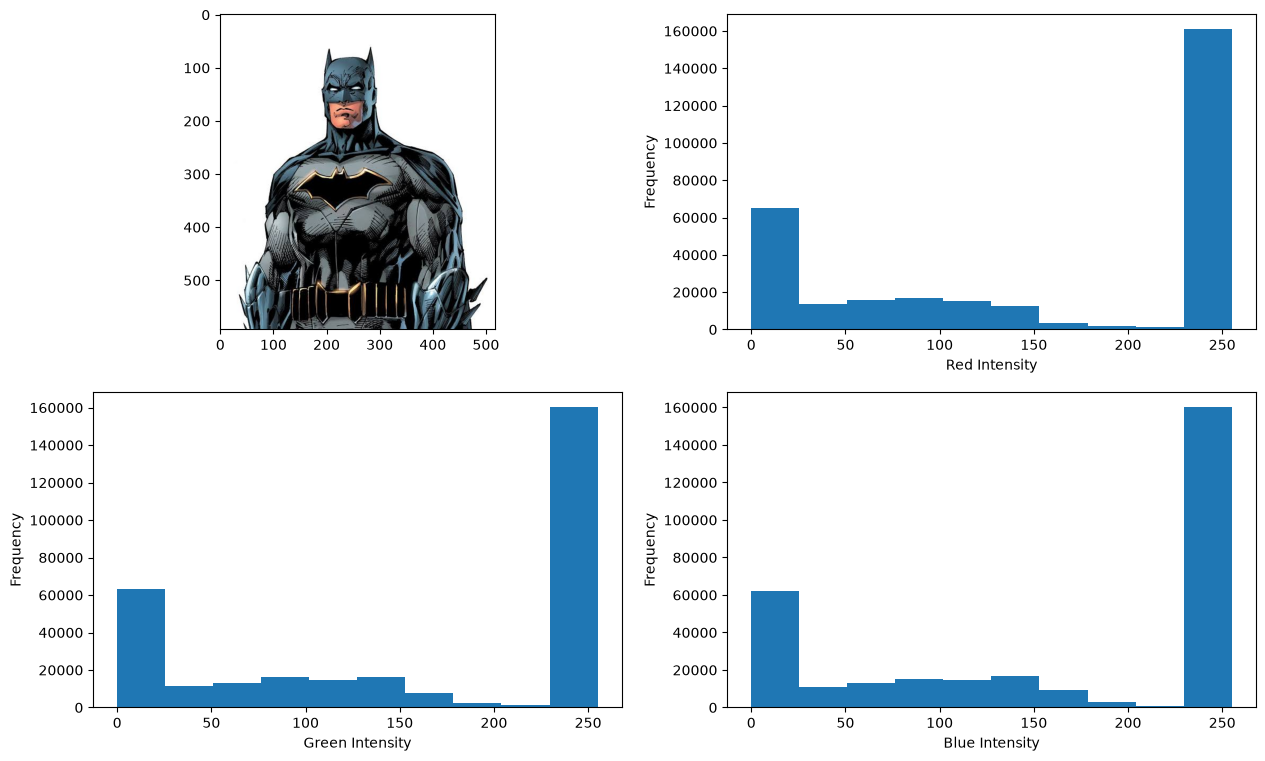

In [48]:
# lets plot a histogram of intensities of RGB colors in the image
plt.figure(figsize=(15,9))

im = im[:, :, [2, 1, 0]]

plt.subplot(2,2,1)
plt.imshow(im)
plt.subplot(2,2,2)
# The ravel command rearanges our image into a long column vector of intensities
plt.hist(im[:,:,0].ravel())
plt.xlabel('Red Intensity')
plt.ylabel('Frequency')
plt.subplot(2,2,3)
plt.hist(im[:,:,1].ravel())
plt.xlabel('Green Intensity')
plt.ylabel('Frequency')
plt.subplot(2,2,4)
plt.hist(im[:,:,2].ravel())
plt.xlabel('Blue Intensity')
plt.ylabel('Frequency')
plt.show()

We know the black color is formed when all the RGB colors have high intensities. Let's try and extract that patch. As it is evident, batman inclines towards many dark color themes agreeing with the intensity plot.

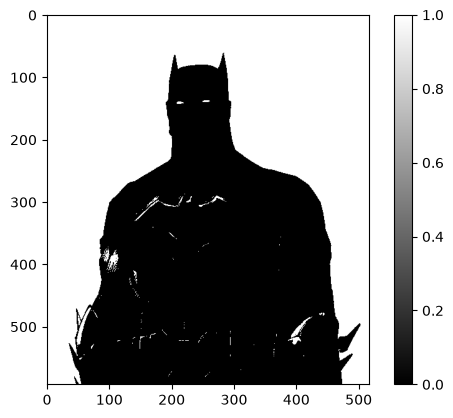

In [55]:
im_black = (im[:, :, 0] > 180) & (im[:, :, 1] > 180) & (im[:, :, 2] > 180)
plt.imshow(im_black, cmap="grey")
plt.colorbar()
plt.show()

# Week 2

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cv2

In [2]:
im = cv2.imread('../Perception/test_images/ana.jpg')

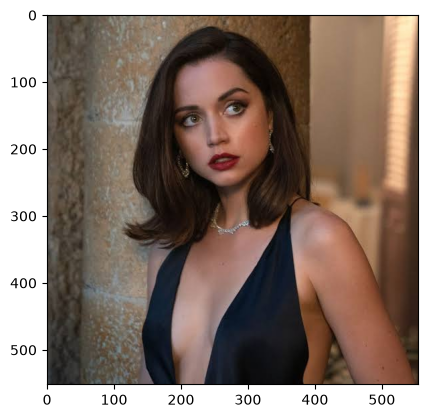

In [3]:
plt.imshow(im[:, :, [2, 1, 0]])

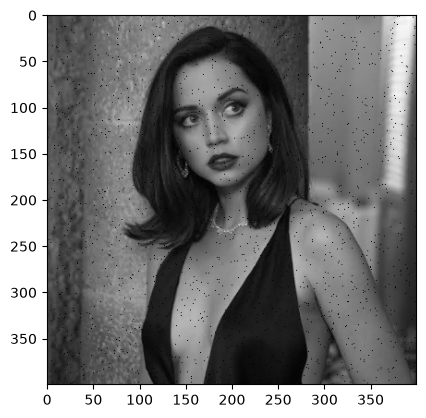

In [16]:
im_resize = cv2.resize(im, (400, 400))
im_gray = cv2.cvtColor(im_resize, cv2.COLOR_BGR2GRAY)
im_gray_noisy = im_gray*(np.random.rand(im_gray.shape[0], im_gray.shape[1])>0.01)
plt.imshow(im_gray_noisy, cmap="gray")

In [17]:

def make_gaussian_kernel(d=15,sigma=3):
    xx,yy = np.meshgrid(np.arange(d),np.arange(d))
    f = 1.0/np.sqrt((2*np.pi)**2*sigma**2*sigma**2)*np.exp(-0.5*((xx-d/2)**2 + (yy-d/2)**2)/sigma**2)
    return f

<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\soham\AppData\Local\Temp\ipykernel_36348\2202905832.py:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title('Gaussian blur 15x15 $\sigma=3$')


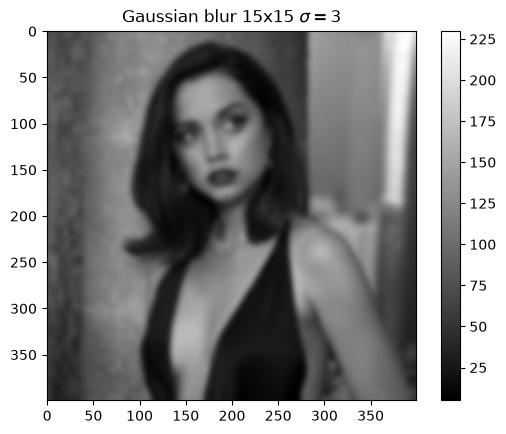

In [19]:
gaussian_response = cv2.filter2D(src=im_gray,ddepth=-1,kernel=kernel)

plt.imshow(gaussian_response,cmap='gray')
plt.title('Gaussian blur 15x15 $\sigma=3$')
plt.colorbar()
plt.show()

<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\soham\AppData\Local\Temp\ipykernel_36348\102602878.py:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.title("Kernel $\sigma=1$")
C:\Users\soham\AppData\Local\Temp\ipykernel_36348\102602878.py:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will no

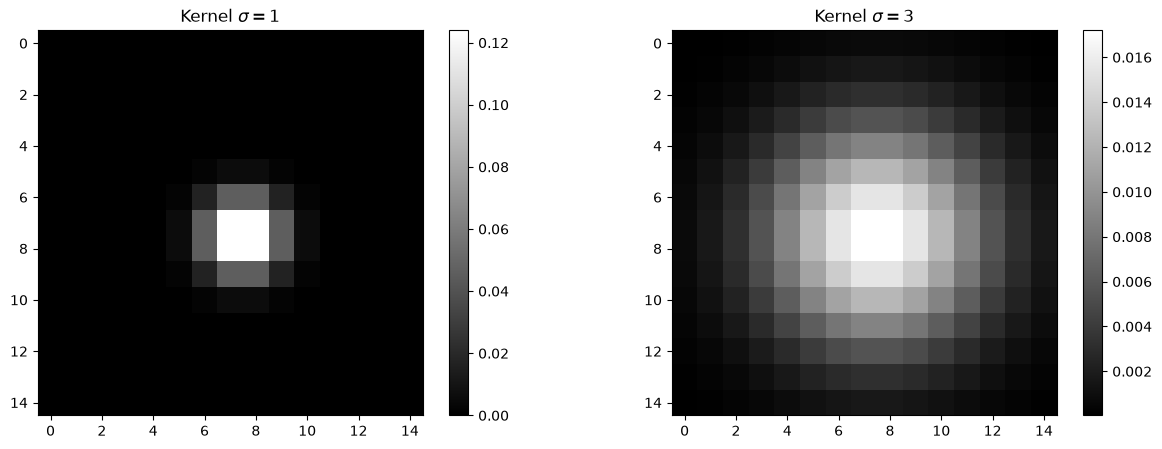

In [20]:
kernel_1 = make_gaussian_kernel(15,1)
kernel_3 = make_gaussian_kernel(15,3)
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(kernel_1,cmap='gray')
plt.title("Kernel $\sigma=1$")
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(kernel_3,cmap='gray')
plt.title("Kernel $\sigma=3$")
plt.colorbar()
plt.show()


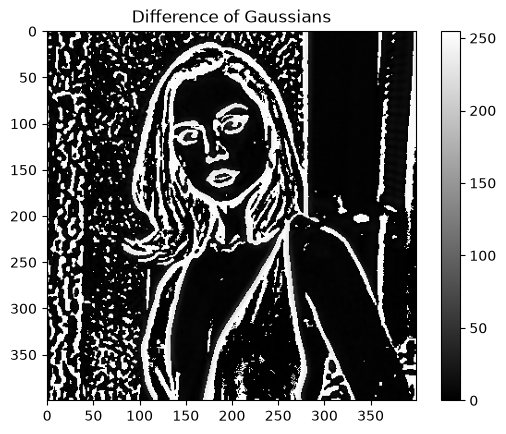

In [21]:
gaussian_response_1 = cv2.filter2D(src=im_gray,ddepth=-1,kernel=kernel_1)
gaussian_response_2 = cv2.filter2D(src=im_gray,ddepth=-1,kernel=kernel_3)

dog = gaussian_response_1-gaussian_response_2

plt.imshow(dog,cmap='gray')
plt.title('Difference of Gaussians')
plt.colorbar()
plt.show()

# Week 4

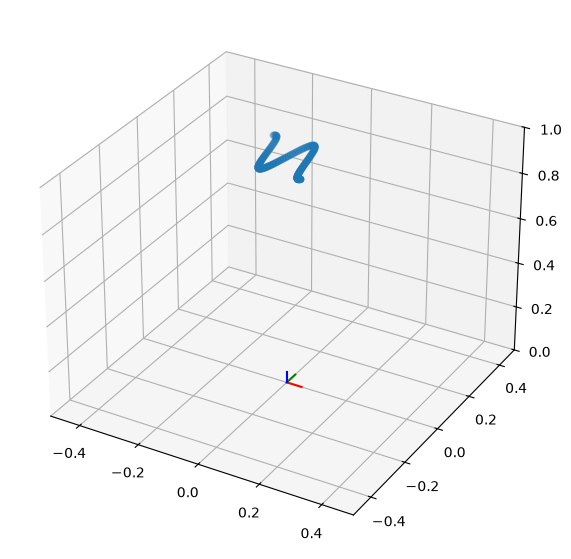

In [22]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")

x = np.linspace(-0.1,0.1,100)
y = 0.1*np.sin(50*x)
z = np.ones(100)

ax.scatter3D(x,y,z)
ax.plot([0,0.05],[0,0],[0,0],'r')
ax.plot([0,0],[0,0.05],[0,0],'g')
ax.plot([0,0],[0,0],[0,0.05],'b')
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
ax.set_zlim(0,1)
plt.show()

We now have 100 different coordinate vectors: (3, 100)


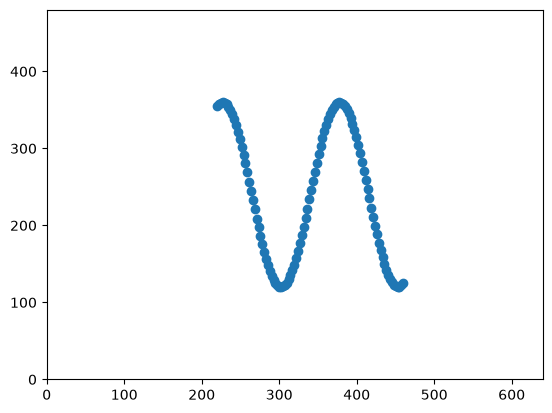

In [23]:
K = np.array([[1200,0,340],[0,1200,240],[0,0,1]])

# Create a coordinate vector for all points
X = np.vstack([x,y,z])

print("We now have 100 different coordinate vectors:",X.shape)

# Project into image plane
im_coords_scaled = K@X
im_coords = im_coords_scaled/im_coords_scaled[2,:]

plt.plot(im_coords[0,:],im_coords[1,:],'o')
plt.xlim(0,640)
plt.ylim(0,480)
plt.show()